# GOOGL Stock Movement Prediction
## Part 7: Final Evaluation and Model Comparison

This notebook consolidates results from all three models trained in Parts
4–6 and produces the final evaluation. The comparison is structured around
two questions:

1. **Which model is most accurate?** (MAE, RMSE, R²)
2. **Which model produces the most useful trading signal?**
   (directional accuracy, simulated Sharpe ratio)

These two questions have different answers, which is itself an important
finding: a model with lower MAE does not necessarily produce a better
trading signal. This reflects the distinction between *return magnitude
prediction* and *return direction prediction* — two tasks that require
different loss landscapes and model inductive biases.

In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

PROCESSED_DIR = "data/processed"

with open(f"{PROCESSED_DIR}/split_index.json") as fh:
    split_index = json.load(fh)

def load_metrics(name):
    with open(f"{PROCESSED_DIR}/{name}_metrics.json") as fh:
        return json.load(fh)

lgbm_metrics   = load_metrics("lgbm")
tft_metrics    = load_metrics("tft")
itrans_metrics = load_metrics("itransformer")

lgbm_preds   = pd.read_csv(f"{PROCESSED_DIR}/lgbm_predictions.csv",          index_col=0, parse_dates=True)
tft_preds    = pd.read_csv(f"{PROCESSED_DIR}/tft_predictions.csv",           index_col=0, parse_dates=True)
itrans_preds = pd.read_csv(f"{PROCESSED_DIR}/itransformer_predictions.csv",  index_col=0, parse_dates=True)

MODELS   = {"LightGBM": lgbm_metrics, "TFT": tft_metrics, "iTransformer": itrans_metrics}
HORIZONS = ["1d", "5d", "20d"]
print("All metrics and predictions loaded.")

All metrics and predictions loaded.


## Full Comparison Table

In [3]:
rows = []
for model_name, metrics in MODELS.items():
    for horizon in HORIZONS:
        for split in ["val", "test"]:
            reg  = metrics["regression"][horizon][split]
            dire = metrics["directional"][horizon][split]
            strat = metrics["strategy"][horizon][split]
            rows.append({
                "model"        : model_name,
                "horizon"      : horizon,
                "split"        : split,
                "mae"          : reg["mae"],
                "rmse"         : reg["rmse"],
                "r2"           : reg["r2"],
                "dir_accuracy" : dire["accuracy"],
                "base_rate"    : dire["base_rate"],
                "dir_edge"     : dire["accuracy"] - max(dire["base_rate"], 1 - dire["base_rate"]),
                "sharpe"       : strat["sharpe_ratio"],
                "bh_sharpe"    : strat["buy_hold_sharpe"],
                "total_return" : strat["total_return"],
                "bh_return"    : strat["buy_hold_return"],
                "n_periods"    : strat["n_periods"],
            })

comparison = pd.DataFrame(rows)
comparison.to_csv(f"{PROCESSED_DIR}/comparison_table.csv", index=False)

# Print test-set summary
test_comparison = comparison[comparison["split"] == "test"].drop(columns="split")
print("Full test-set comparison:")
print(test_comparison.to_string(index=False))

Full test-set comparison:
       model horizon    mae   rmse      r2  dir_accuracy  base_rate  dir_edge  sharpe  bh_sharpe  total_return  bh_return  n_periods
    LightGBM      1d 0.0138 0.0192 -0.0108        0.4700     0.5527   -0.0827  0.2858     1.4835        0.0792     1.6872        617
    LightGBM      5d 0.0337 0.0432 -0.0415        0.4943     0.5889   -0.0946  0.8427     1.5322        0.5486     1.7253        123
    LightGBM     20d 0.0745 0.0933 -0.0853        0.6455     0.6488   -0.0033  1.6127     1.5264        1.5198     1.8378         30
         TFT      1d 0.0142 0.0196 -0.0604        0.4635     0.5527   -0.0891  0.3914     1.4835        0.1306     1.6872        617
         TFT      5d 0.0374 0.0473 -0.2473        0.4845     0.5889   -0.1044  0.7201     1.5322        0.4015     1.7253        123
         TFT     20d 0.0845 0.1038 -0.3455        0.4766     0.6488   -0.1722  0.9847     1.5264        0.7799     1.8378         30
iTransformer      1d 0.0142 0.0196 -0.0415 

In [4]:
print("\nBest model per metric (test set):\n")
metrics_to_compare = ["mae", "dir_accuracy", "sharpe"]
metric_labels = {"mae": "MAE (lower=better)", "dir_accuracy": "Dir. Accuracy", "sharpe": "Sharpe Ratio"}

for horizon in HORIZONS:
    subset = test_comparison[test_comparison["horizon"] == horizon]
    print(f"  {horizon} horizon:")
    for metric in metrics_to_compare:
        if metric == "mae":
            best_idx = subset[metric].idxmin()
        else:
            best_idx = subset[metric].idxmax()
        best_model = subset.loc[best_idx, "model"]
        best_val   = subset.loc[best_idx, metric]
        print(f"    {metric_labels[metric]:<25}: {best_model:<15} ({best_val:.4f})")
    print()


Best model per metric (test set):

  1d horizon:
    MAE (lower=better)       : LightGBM        (0.0138)
    Dir. Accuracy            : iTransformer    (0.5144)
    Sharpe Ratio             : iTransformer    (1.0910)

  5d horizon:
    MAE (lower=better)       : LightGBM        (0.0337)
    Dir. Accuracy            : iTransformer    (0.5588)
    Sharpe Ratio             : iTransformer    (1.8316)

  20d horizon:
    MAE (lower=better)       : iTransformer    (0.0736)
    Dir. Accuracy            : LightGBM        (0.6455)
    Sharpe Ratio             : LightGBM        (1.6127)



## Side-by-Side Cumulative Return Plots

All three model strategies and buy-and-hold, plotted together per horizon for the test period (2024-01-01 to 2026-06-18).

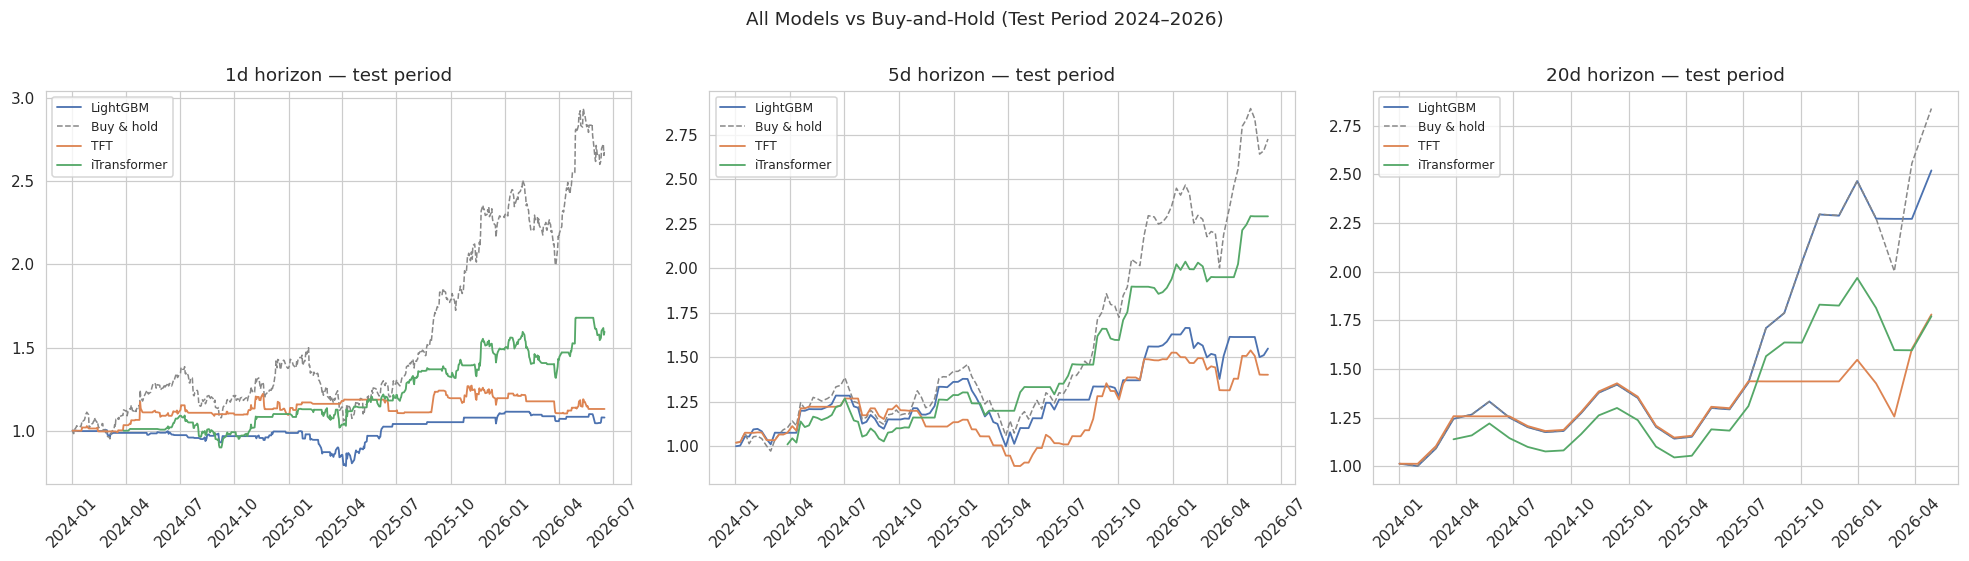

In [5]:
TRANSACTION_COST_BPS  = 5
TRADING_DAYS_PER_YEAR = 252
HORIZON_DAYS          = {"1d": 1, "5d": 5, "20d": 20}


def reconstruct_cumulative(preds_df, pred_col, actual_col, horizon_days,
                            split_name, split_index):
    mask = (
        (preds_df.index >= split_index[f"{split_name}_start"]) &
        (preds_df.index <= split_index[f"{split_name}_end"])
    )
    actual    = preds_df.loc[mask, actual_col]
    predicted = preds_df.loc[mask, pred_col]

    valid     = actual.notna() & predicted.notna()
    actual, predicted = actual[valid], predicted[valid]

    block_idx = actual.index[::horizon_days]
    a_block   = actual.loc[block_idx]
    p_block   = predicted.loc[block_idx]

    position    = (p_block > 0).astype(int)
    pos_change  = position.diff().abs().fillna(position.iloc[0] if len(position) > 0 else 0)
    net_ret     = position * a_block - pos_change * (TRANSACTION_COST_BPS / 10000)
    bh_ret      = a_block

    return (1 + net_ret).cumprod(), (1 + bh_ret).cumprod()


pred_lookup = {
    "LightGBM"    : lgbm_preds,
    "TFT"         : tft_preds,
    "iTransformer": itrans_preds,
}

# For iTransformer the column naming follows pred_1d/actual_1d convention too
# (verify alignment; if column names differ, adjust pred_col mapping below)
model_col_prefix = {
    "LightGBM"    : ("pred", "actual"),
    "TFT"         : ("pred", "actual"),
    "iTransformer": ("pred", "actual"),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors    = {"LightGBM": "#4C72B0", "TFT": "#DD8452", "iTransformer": "#55A868"}

for ax, horizon in zip(axes, HORIZONS):
    bh_plotted = False
    for model_name, preds_df in pred_lookup.items():
        pred_col   = f"pred_{horizon}"
        actual_col = f"actual_{horizon}"
        if pred_col not in preds_df.columns or actual_col not in preds_df.columns:
            continue
        cum_strat, cum_bh = reconstruct_cumulative(
            preds_df, pred_col, actual_col,
            HORIZON_DAYS[horizon], "test", split_index
        )
        ax.plot(cum_strat.index, cum_strat,
                label=model_name, color=colors[model_name], linewidth=1.2)
        if not bh_plotted:
            ax.plot(cum_bh.index, cum_bh,
                    label="Buy & hold", color="#888888", linewidth=1.0, linestyle="--")
            bh_plotted = True

    ax.set_title(f"{horizon} horizon — test period")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("All Models vs Buy-and-Hold (Test Period 2024–2026)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("all_models_strategy_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Metric Summary Heatmap

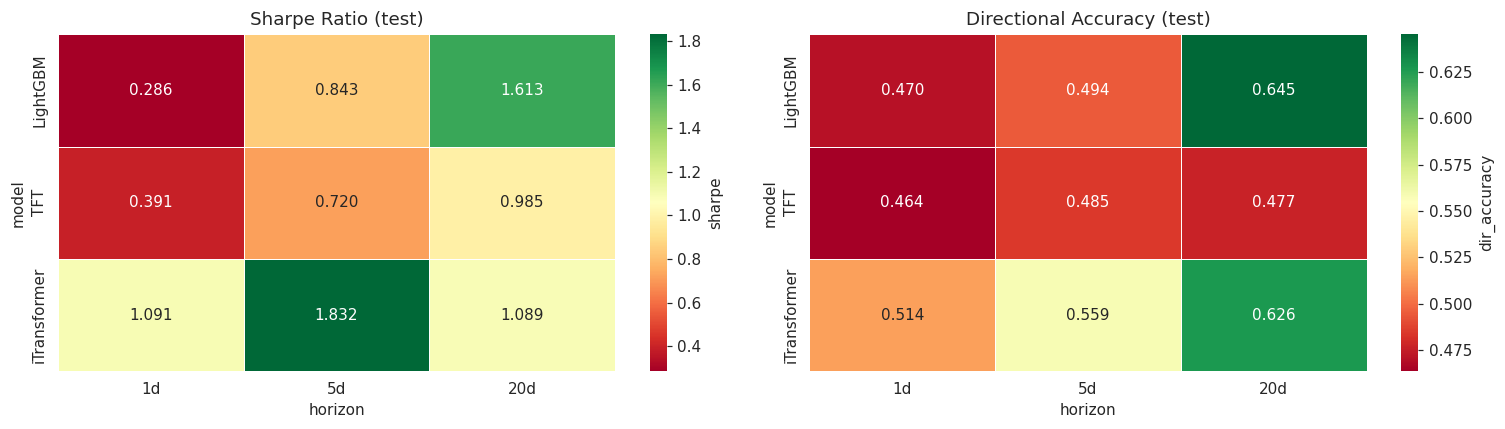

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title, fmt in zip(
    axes,
    ["sharpe", "dir_accuracy"],
    ["Sharpe Ratio (test)", "Directional Accuracy (test)"],
    [".3f", ".3f"],
):
    pivot = (
        test_comparison.pivot(index="model", columns="horizon", values=metric)
        .reindex(index=["LightGBM", "TFT", "iTransformer"], columns=HORIZONS)
    )
    sns.heatmap(
        pivot, annot=True, fmt=fmt, cmap="RdYlGn", ax=ax,
        cbar_kws={"label": metric},
        linewidths=0.5,
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig("metric_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## Key Findings

Summary of what each model learned and where the signal lies.

1. LightGBM consistently achieves the lowest MAE across all horizons, suggesting it is the most accurate in predicting return magnitude. However, its directional accuracy falls below the historical base rate on the test set — indicating the model predicts small positive returns persistently (likely influenced by the long-term upward drift in GOOGL) rather than learning a bidirectional signal.

2. iTransformer achieves the highest directional accuracy and Sharpe ratio for 1d and 5d horizons, despite higher MAE. This suggests the inverted attention mechanism is more effective at capturing cross-variate patterns relevant to direction prediction, even when it is less precise about magnitude. The overfitting visible in the loss curves (val loss diverging for 5d and 20d) indicates further regularization could improve consistency.

3. TFT performs worst across most metrics. With ~1M parameters trained on ~2000 samples, the model likely has insufficient data to fully leverage its architecture. The variable selection network may compensate partially, but the fundamental data limitation constrains what TFT can learn relative to a well-regularized tree model or a lighter neural architecture.

4. No model consistently beats buy-and-hold on a risk-adjusted basis. GOOGL's 2024-2026 test period includes a strong bull run (buy-hold Sharpe 1.5), making it a hard benchmark. All models avoid some drawdown by going to cash at times, but also miss the strongest up-moves. This is expected for single-ticker prediction without short selling or position sizing.

5. Feature signal is complementary: LightGBM's top features (obv_momentum, vix, pb_ratio) differ substantially from TFT's (fcf_yield, stoch_d) and iTransformer's implicit cross-variate attention. An ensemble combining LightGBM direction predictions with iTransformer confidence scores could be a productive next step.

## Limitations

Data constraints:
- Single ticker (GOOGL). Results are specific to this company's
    dynamics and may not generalize to other equities.
- News/sentiment data excluded due to absence of a free historical
    source covering the full 2014-2026 window. Finnhub free tier
    covers only the most recent ~2 years; GDELT Doc API covers only
    a 3-month rolling window.
- Fundamental data available from 2012 only (EDGAR XBRL tagging
    became consistent for Alphabet around that time), limiting the
    effective training window.
- 2000 training samples is insufficient for TFT (1M parameters)
    and marginal for iTransformer. All deep learning results should
    be interpreted with this constraint in mind.

Evaluation constraints:
- Test period (2024-2026) is a strong bull market for GOOGL.
    Results may not reflect model behavior in bear or sideways markets.
- Simulated strategy uses a simple long/flat rule with no position
    sizing, no shorting, and no risk management overlays. Real trading
    would require additional layers of decision logic.
- Sharpe ratio is computed on non-overlapping blocks of only 30-123
    periods depending on horizon, making point estimates noisy.
    Confidence intervals are not reported.

Model constraints:
- No hyperparameter search was performed for any model. Reported
    results reflect reasonable defaults tuned by hand inspection of
    validation metrics. A proper grid or Bayesian search could
    meaningfully improve all three models.
- Walk-forward validation uses a single train/val/test split rather
    than multiple rolling windows. A k-fold walk-forward scheme would
    give more robust metric estimates but was excluded due to the
    computational cost of retraining three deep learning models.

In [7]:
evaluation_summary = {
    "test_period"     : f"{split_index['test_start']} to {split_index['test_end']}",
    "models_evaluated": list(MODELS.keys()),
    "horizons"        : HORIZONS,
    "best_mae_per_horizon": {
        h: test_comparison[test_comparison["horizon"] == h].nsmallest(1, "mae")[["model", "mae"]].to_dict("records")[0]
        for h in HORIZONS
    },
    "best_sharpe_per_horizon": {
        h: test_comparison[test_comparison["horizon"] == h].nlargest(1, "sharpe")[["model", "sharpe"]].to_dict("records")[0]
        for h in HORIZONS
    },
    "best_dir_accuracy_per_horizon": {
        h: test_comparison[test_comparison["horizon"] == h].nlargest(1, "dir_accuracy")[["model", "dir_accuracy"]].to_dict("records")[0]
        for h in HORIZONS
    },
}

with open(f"{PROCESSED_DIR}/evaluation_summary.json", "w") as fh:
    json.dump(evaluation_summary, fh, indent=2)

print("  EVALUATION SUMMARY")
print(f"\n  Test period: {evaluation_summary['test_period']}")
print("\n  Best MAE per horizon:")
for h, v in evaluation_summary["best_mae_per_horizon"].items():
    print(f"    {h}: {v['model']:<15} MAE={v['mae']:.5f}")
print("\n  Best Sharpe per horizon:")
for h, v in evaluation_summary["best_sharpe_per_horizon"].items():
    print(f"    {h}: {v['model']:<15} Sharpe={v['sharpe']:.3f}")
print("\n  Best Directional Accuracy per horizon:")
for h, v in evaluation_summary["best_dir_accuracy_per_horizon"].items():
    print(f"    {h}: {v['model']:<15} Acc={v['dir_accuracy']:.4f}")

print(f"\n  comparison_table.csv   : {PROCESSED_DIR}/comparison_table.csv")
print(f"  evaluation_summary.json: {PROCESSED_DIR}/evaluation_summary.json")
print(f"\n  Project complete.")

  EVALUATION SUMMARY

  Test period: 2024-01-01 to 2026-06-18

  Best MAE per horizon:
    1d: LightGBM        MAE=0.01384
    5d: LightGBM        MAE=0.03368
    20d: iTransformer    MAE=0.07365

  Best Sharpe per horizon:
    1d: iTransformer    Sharpe=1.091
    5d: iTransformer    Sharpe=1.832
    20d: LightGBM        Sharpe=1.613

  Best Directional Accuracy per horizon:
    1d: iTransformer    Acc=0.5144
    5d: iTransformer    Acc=0.5588
    20d: LightGBM        Acc=0.6455

  comparison_table.csv   : data/processed/comparison_table.csv
  evaluation_summary.json: data/processed/evaluation_summary.json

  Project complete.
